In [3]:
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

# Simulated alignments

In [4]:
# Check alignment lengths for simulated data -- after removing sites that are not informative
l = []
for file in os.listdir("/fh/fast/matsen_e/shared/dpvt/datasets/"):
    if file.endswith("_spr.p"):
        print(file)
        with open("/fh/fast/matsen_e/shared/dpvt/datasets/" + file, "rb") as f:
            trees = pickle.load(f)
        num_seqs = int(file.split("_seq")[0].split("_")[-1])
        num_sites = int(file.split("_sites")[0].split("_")[-1])
        num_alignments = int(file.split("_algnmnts")[0].split("_")[-1])
        for tree in trees:
            l.append([num_seqs, num_sites, num_alignments, len(tree.sequence)])
df = pd.DataFrame.from_records(l, columns = ["num_seqs", "num_sites", "num_alignments", "seq_length"])


larch_alisim_alignment_15_seq_20_sites_200_algnmnts_2025-01-08_train_spr.p
larch_alisim_alignment_10_seq_100_sites_200_algnmnts_2025-01-08_test_spr.p
larch_alisim_alignment_5_seq_50_sites_200_algnmnts_2025-01-08_test_spr.p
larch_alisim_alignment_15_seq_50_sites_200_algnmnts_2025-01-08_test_spr.p
larch_alisim_alignment_10_seq_50_sites_200_algnmnts_2025-01-08_test_spr.p
larch_alisim_alignment_5_seq_20_sites_200_algnmnts_2025-01-08_train_spr.p
larch_alisim_alignment_15_seq_100_sites_200_algnmnts_2025-01-08_train_spr.p
larch_alisim_alignment_10_seq_20_sites_200_algnmnts_2025-01-08_test_spr.p
larch_alisim_alignment_5_seq_50_sites_200_algnmnts_2025-01-08_train_spr.p
larch_alisim_alignment_5_seq_100_sites_200_algnmnts_2025-01-08_test_spr.p
larch_alisim_alignment_10_seq_100_sites_200_algnmnts_2025-01-08_train_spr.p
larch_alisim_alignment_10_seq_50_sites_200_algnmnts_2025-01-08_train_spr.p
larch_alisim_alignment_5_seq_100_sites_200_algnmnts_2025-01-08_train_spr.p
larch_alisim_alignment_15_seq_1

/home/lcollien/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lcollien/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lcollien/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


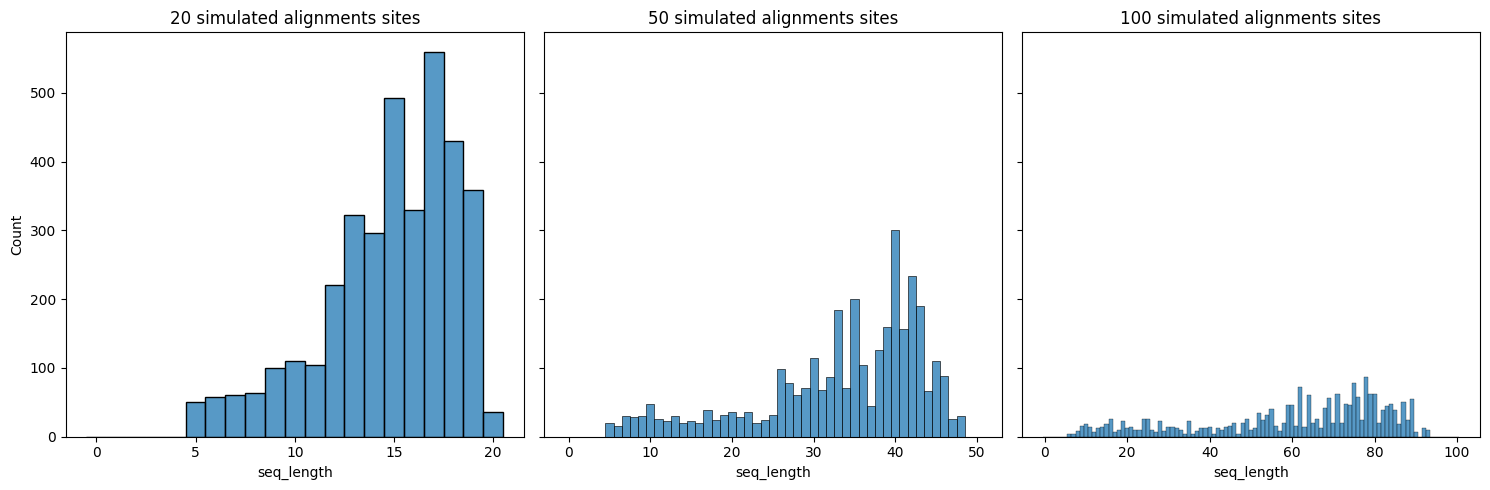

In [5]:

# Create a figure with subplots
unique_sites = df["num_sites"].unique()
unique_sites.sort()
n_sites = len(unique_sites)

fig, axes = plt.subplots(1, n_sites, figsize=(5 * n_sites, 5), sharey=True)


for ax, num_sites in zip(axes, unique_sites):
    sub_df = df[df["num_sites"] == num_sites]
    sns.histplot(
        data=sub_df,
        x="seq_length",
        binwidth=1,
        binrange=(-0.5, num_sites + 0.5),
        ax=ax
    )
    ax.set_title(f"{num_sites} simulated alignments sites")
    ax.set_xlabel("seq_length")
    ax.set_ylabel("Count" if ax == axes[0] else "")

plt.tight_layout()
plt.show()


# Perfect Phylogenies

In [6]:
# Check alignment lengths for perfect phylogeny data
l = []
for file in os.listdir("/fh/fast/matsen_e/shared/dpvt/datasets/"):
    if "leaf_perfect" in file:
        print(file)
        with open("/fh/fast/matsen_e/shared/dpvt/datasets/" + file, "rb") as f:
            trees = pickle.load(f)
        num_seqs = int(file.split("leaf")[0])
        try:
            num_trees = int(file.split("_distinct")[0].split("_")[-1])
        except:
            continue
        for tree in trees:
            l.append([num_seqs, num_trees, len(tree.sequence)])
df = pd.DataFrame.from_records(l, columns = ["num_seqs", "num_trees", "seq_length"])
df

10leaf_perfect_1000_distinct_trees.p
30leaf_perfect_distinct_trees_train.p
10leaf_perfect_100_distinct_trees_test.p
15leaf_perfect_100_distinct_trees_test.p
5leaf_perfect_500_distinct_trees.p
10leaf_perfect_distinct_trees.p
5leaf_perfect_100_distinct_trees.p
30leaf_perfect_distinct_trees_test.p
10leaf_perfect.p
10leaf_perfect_500_distinct_trees.p
15leaf_perfect_1000_distinct_trees.p
10leaf_perfect_distinct_trees_train.p
10leaf_perfect_distinct_trees_test.p
30leaf_perfect.p
15leaf_perfect_500_distinct_trees.p
15leaf_perfect_100_distinct_trees.p
5leaf_perfect_1000_distinct_trees.p
30leaf_perfect_distinct_trees.p
5leaf_perfect_test.p
5leaf_perfect_train.p
10leaf_perfect_100_distinct_trees.p
5leaf_perfect_100_distinct_trees_test.p


,num_seqs,num_trees,seq_length
0,10,1000,7
1,10,1000,6
2,10,1000,6
3,10,1000,6
4,10,1000,5
...,...,...,...
5095,5,100,2
5096,5,100,3
5097,5,100,3
5098,5,100,2


/home/lcollien/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lcollien/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lcollien/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


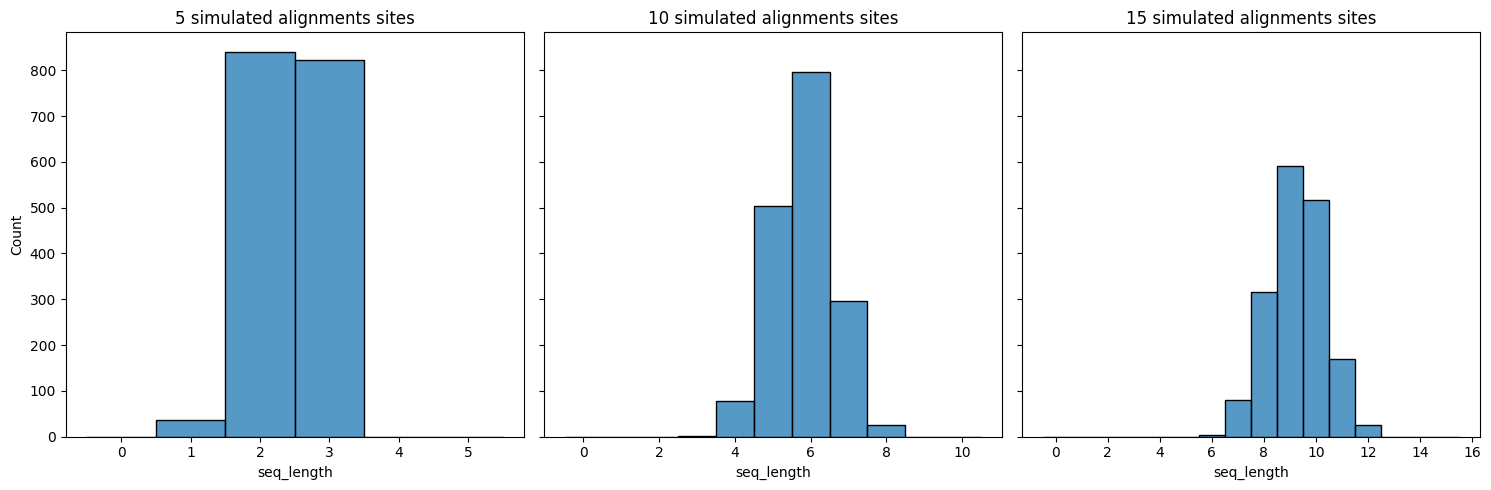

In [7]:
# Create a figure with subplots
unique_sites = df["num_seqs"].unique()
unique_sites.sort()
n_sites = len(unique_sites)

fig, axes = plt.subplots(1, n_sites, figsize=(5 * n_sites, 5), sharey=True)


for ax, num_seqs in zip(axes, unique_sites):
    sub_df = df[df["num_seqs"] == num_seqs]
    sns.histplot(
        data=sub_df,
        x="seq_length",
        binwidth=1,
        binrange=(-0.5, num_seqs + 0.5),
        ax=ax,
    )
    ax.set_title(f"{num_seqs} simulated alignments sites")
    ax.set_xlabel("seq_length")
    ax.set_ylabel("Count" if ax == axes[0] else "")

plt.tight_layout()
plt.show()

## Check overlap between training and testing data

In [8]:
data_dir = "/fh/fast/matsen_e/shared/dpvt/datasets/"
files = os.listdir(data_dir)
files = [f for f in files if "leaf_perfect" in f]
pairs = {}

# get pairs of file names for training and testing
for f in files:
    try:
        num_trees = int(f.split("_distinct")[0].split("_")[-1])
    except:
        continue
    num_leaves = int(f.split("leaf")[0])
    test_f = f"{num_leaves}leaf_perfect_100_distinct_trees_test.p"
    print(test_f)
    if test_f in files:
        if test_f in files:
            pairs[data_dir + f] = data_dir + test_f

# Create dict with keys = dataset IDs and values = list of RF distances between training trees and testing trees on same number of leaves
dist_dict = {}
for p in pairs:
    with open(p, "rb") as f:
        train_trees = pickle.load(f)
    with open(pairs[p], "rb") as f:
        test_trees = pickle.load(f)
    rf_distances = []
    for train_t in train_trees:
        for test_t in test_trees:
            rf_distances.append(train_t.robinson_foulds(test_t)[0])
    dist_dict[p.split("/")[-1]] = rf_distances


10leaf_perfect_100_distinct_trees_test.p
10leaf_perfect_100_distinct_trees_test.p
15leaf_perfect_100_distinct_trees_test.p
5leaf_perfect_100_distinct_trees_test.p
5leaf_perfect_100_distinct_trees_test.p
10leaf_perfect_100_distinct_trees_test.p
15leaf_perfect_100_distinct_trees_test.p
15leaf_perfect_100_distinct_trees_test.p
15leaf_perfect_100_distinct_trees_test.p
5leaf_perfect_100_distinct_trees_test.p
10leaf_perfect_100_distinct_trees_test.p
5leaf_perfect_100_distinct_trees_test.p


In [9]:
num_leaves_set = set([int(l.split("leaf")[0]) for l in dist_dict.keys()])
num_trees_set = set([int(l.split("_")[2]) for l in dist_dict.keys()])

df = pd.DataFrame([
    {'data': key, 'rf_dist': value, "num_leaves": num_leaves, "num_trees": num_trees}
    for key, values in dist_dict.items()
    for value in values
    for num_leaves in num_leaves_set if str(num_leaves)+"leaf" in key
    for num_trees in num_trees_set if str(num_trees)+"_distinct_trees" in key
])
df

,data,rf_dist,num_leaves,num_trees
0,10leaf_perfect_1000_distinct_trees.p,16,10,1000
1,10leaf_perfect_1000_distinct_trees.p,16,10,1000
2,10leaf_perfect_1000_distinct_trees.p,16,10,1000
3,10leaf_perfect_1000_distinct_trees.p,14,10,1000
4,10leaf_perfect_1000_distinct_trees.p,16,10,1000
...,...,...,...,...
679995,5leaf_perfect_100_distinct_trees_test.p,6,5,100
679996,5leaf_perfect_100_distinct_trees_test.p,2,5,100
679997,5leaf_perfect_100_distinct_trees_test.p,6,5,100
679998,5leaf_perfect_100_distinct_trees_test.p,6,5,100


/home/lcollien/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/lcollien/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lcollien/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/lcollien/.local/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarni

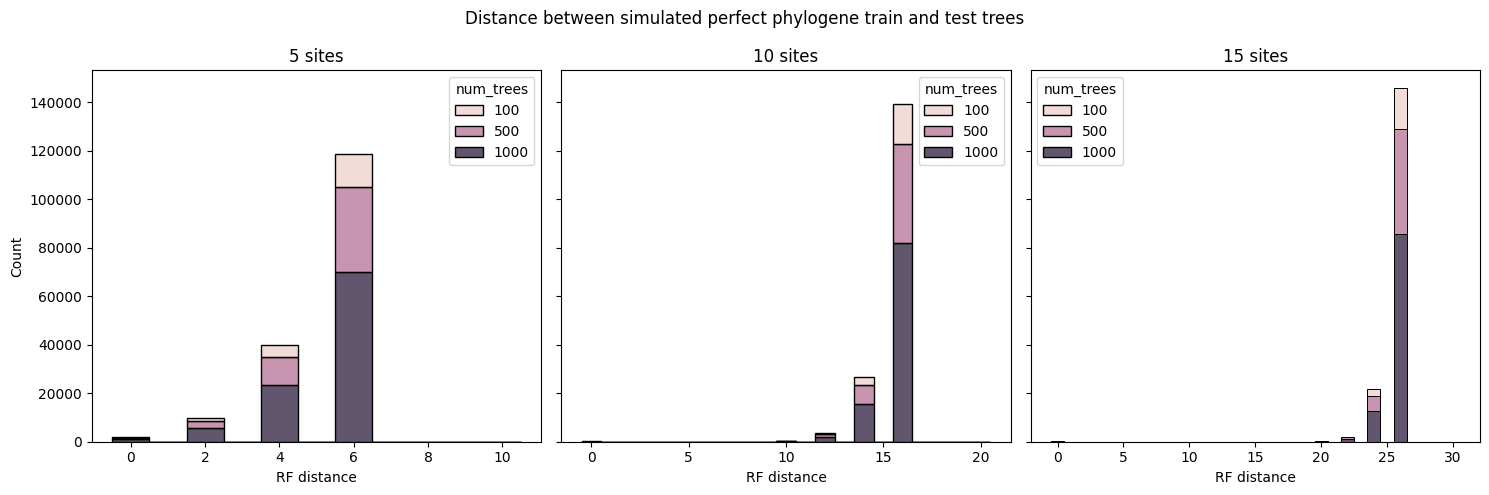

In [10]:
num_leaves_l = list(num_leaves_set)
num_leaves_l.sort()
fig, axes = plt.subplots(1, n_sites, figsize=(5 * len(num_leaves_l), 5), sharey=True)

for ax, num_leaves in zip(axes, num_leaves_l):
    sub_df = df[df["num_leaves"] == num_leaves]
    # print(sub_df)
    sns.histplot(
        data=sub_df,
        x="rf_dist",
        binwidth=1,
        binrange=(-0.5, (2 * num_leaves) + 0.5),
        ax=ax,
        hue="num_trees",
        multiple="stack"
    )
    ax.set_title(f"{num_leaves} sites")
    ax.set_xlabel("RF distance")
    ax.set_ylabel("Count" if ax == axes[0] else "")
fig.suptitle("Distance between simulated perfect phylogene train and test trees")
plt.tight_layout()
plt.show()